# Vehicle Helmet Detection — YOLOv8



## 1. Install Dependencies

In [1]:
# Install YOLOv8 (Ultralytics)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q'])
print('✅ ultralytics installed')

✅ ultralytics installed


## 2. Configuration

Set the path to your dataset ZIP file below. The file should be in the same directory as this notebook, or provide an absolute path.

In [5]:
import os

# -------------------------------------------------------
# ✏️  SET YOUR ZIP FILE NAME / PATH HERE
# -------------------------------------------------------
ZIP_FILE = 'Helmet detection.yolov8.zip'   # <- change if your file has a different name
EXTRACT_PATH = os.path.join(os.getcwd(), 'helmet_detection_dataset')
# -------------------------------------------------------

assert os.path.exists(ZIP_FILE), (
    f"❌ ZIP file not found: '{ZIP_FILE}'\n"
    f"   Place your dataset zip in: {os.getcwd()}"
)

print(f'📦 ZIP file   : {ZIP_FILE}')
print(f'📂 Extract to : {EXTRACT_PATH}')

📦 ZIP file   : Helmet detection.yolov8.zip
📂 Extract to : C:\Users\ASUS\helmet_detection_dataset


## 3. Extract the Dataset

In [6]:
import zipfile

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print('✅ Dataset extracted!')

✅ Dataset extracted!


## 4. Inspect Folder Structure

In [8]:
for root, dirs, files in os.walk(EXTRACT_PATH):
    level = root.replace(EXTRACT_PATH, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/ → {len(files)} files')

helmet_detection_dataset/ → 2 files
  .ipynb_checkpoints/ → 0 files
  test/ → 0 files
    images/ → 0 files
    labels/ → 0 files
  train/ → 0 files
    .ipynb_checkpoints/ → 0 files
    images/ → 4370 files
      .ipynb_checkpoints/ → 1 files
    labels/ → 4370 files
  valid/ → 0 files
    images/ → 0 files
    labels/ → 0 files


## 5. Train / Val / Test Split (70% / 20% / 10%)

In [9]:
import shutil, random

random.seed(42)   # reproducible shuffle

# ── Locate raw source images & labels ─────────────────────────────────────────
# The zip may extract into 'train/' or directly into the root — we search both.
def find_source_dirs(base_path):
    """Return (images_dir, labels_dir) regardless of zip structure."""
    candidates = [
        (os.path.join(base_path, 'train', 'images'),
         os.path.join(base_path, 'train', 'labels')),
        (os.path.join(base_path, 'images'),
         os.path.join(base_path, 'labels')),
    ]
    for img_dir, lbl_dir in candidates:
        if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
            return img_dir, lbl_dir
    raise FileNotFoundError(
        f'Could not find images/labels folders inside {base_path}.\n'
        f'Please check the extracted folder structure above.'
    )

src_images, src_labels = find_source_dirs(EXTRACT_PATH)
print(f'📂 Source images : {src_images}')
print(f'📂 Source labels : {src_labels}')

# ── Collect all images ────────────────────────────────────────────────────────
images = [f for f in os.listdir(src_images)
          if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)
print(f'🖼️  Total images found: {len(images)}')

# ── Split ratios ──────────────────────────────────────────────────────────────
train_split = 0.7
val_split   = 0.2

train_end   = int(train_split * len(images))
val_end     = int((train_split + val_split) * len(images))

train_files = images[:train_end]
val_files   = images[train_end:val_end]
test_files  = images[val_end:]

# ── Output folders (always separate from the source) ─────────────────────────
SPLIT_ROOT = os.path.join(os.path.dirname(EXTRACT_PATH), 'helmet_split')

for split in ['train', 'valid', 'test']:
    os.makedirs(os.path.join(SPLIT_ROOT, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(SPLIT_ROOT, split, 'labels'), exist_ok=True)

print(f'📂 Output root   : {SPLIT_ROOT}')

# ── Copy helper (skips if src == dst to avoid SameFileError) ──────────────────
def copy_files(file_list, split):
    copied, skipped = 0, 0
    for img in file_list:
        label   = img.rsplit('.', 1)[0] + '.txt'
        src_img = os.path.join(src_images, img)
        src_lbl = os.path.join(src_labels, label)
        dst_img = os.path.join(SPLIT_ROOT, split, 'images', img)
        dst_lbl = os.path.join(SPLIT_ROOT, split, 'labels', label)

        if not os.path.exists(src_img) or not os.path.exists(src_lbl):
            skipped += 1
            continue

        # Skip if source and destination are literally the same file
        if os.path.abspath(src_img) != os.path.abspath(dst_img):
            shutil.copy2(src_img, dst_img)
        if os.path.abspath(src_lbl) != os.path.abspath(dst_lbl):
            shutil.copy2(src_lbl, dst_lbl)
        copied += 1

    if skipped:
        print(f'   ⚠️  {skipped} image(s) skipped (missing label file)')
    return copied

n_train = copy_files(train_files, 'train')
n_val   = copy_files(val_files,   'valid')
n_test  = copy_files(test_files,  'test')

print('✅ Split completed!')
print(f'   Train : {n_train}')
print(f'   Val   : {n_val}')
print(f'   Test  : {n_test}')

📂 Source images : C:\Users\ASUS\helmet_detection_dataset\train\images
📂 Source labels : C:\Users\ASUS\helmet_detection_dataset\train\labels
🖼️  Total images found: 4368
📂 Output root   : C:\Users\ASUS\helmet_split
✅ Split completed!
   Train : 3057
   Val   : 874
   Test  : 437


## 6. Create `data.yaml`

In [10]:
import yaml

yaml_path = os.path.join(SPLIT_ROOT, 'data.yaml')

data = {
    'path'  : SPLIT_ROOT,
    'train' : 'train/images',
    'val'   : 'valid/images',
    'test'  : 'test/images',
    'nc'    : 2,
    'names' : ['helmet', 'no_helmet']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print('✅ data.yaml created!')
print(f'   Saved to: {yaml_path}')

# Preview
with open(yaml_path) as f:
    print('\n--- data.yaml contents ---')
    print(f.read())


✅ data.yaml created!
   Saved to: C:\Users\ASUS\helmet_split\data.yaml

--- data.yaml contents ---
names:
- helmet
- no_helmet
nc: 2
path: C:\Users\ASUS\helmet_split
test: test/images
train: train/images
val: valid/images



In [11]:
import glob

def count_images(folder):
    return len(glob.glob(os.path.join(folder, "**", "*.jpg"), recursive=True) +
               glob.glob(os.path.join(folder, "**", "*.png"), recursive=True) +
               glob.glob(os.path.join(folder, "**", "*.jpeg"), recursive=True))

splits = {
    "train" : os.path.join(SPLIT_ROOT, "train", "images"),
    "valid" : os.path.join(SPLIT_ROOT, "valid", "images"),
    "test"  : os.path.join(SPLIT_ROOT, "test",  "images"),
}

all_ok = True
for name, path in splits.items():
    n = count_images(path)
    exists = os.path.isdir(path)
    status = "✅" if (exists and n > 0) else "❌"
    print(f"{status}  {name:6s} → {path}")
    print(f"         {n} image(s) found")
    if not exists or n == 0:
        all_ok = False

print()
if not all_ok:
    raise RuntimeError(
        "One or more split folders are empty or missing."
        "Please re-run the Split cell (Cell 5) before training."
    )
else:
    print(f"✅ SPLIT_ROOT : {SPLIT_ROOT}")
    print(f"✅ yaml_path  : {yaml_path}")

✅  train  → C:\Users\ASUS\helmet_split\train\images
         3057 image(s) found
✅  valid  → C:\Users\ASUS\helmet_split\valid\images
         874 image(s) found
✅  test   → C:\Users\ASUS\helmet_split\test\images
         437 image(s) found

✅ SPLIT_ROOT : C:\Users\ASUS\helmet_split
✅ yaml_path  : C:\Users\ASUS\helmet_split\data.yaml


## 7. Train YOLOv8 Model

> **Tip:** Lower `batch` if you run out of VRAM (e.g. `batch=8` for 4 GB GPU, `batch=4` for CPU).

In [14]:
model = YOLO('yolov8s.pt')   # ✅ Start here

results = model.train(
    data    = yaml_path,
    epochs  = 50,        # ⬆ increase from 30 — s model benefits from more epochs
    imgsz   = 640,
    batch   = 8,        # s can handle 16 on 8GB GPU; drop to 8 if OOM
    name    = 'helmet_detector_s',
    project = os.path.join(os.getcwd(), 'runs'),
    patience = 15,       # early stopping — avoids overfitting on 3k images
    augment  = True      # helps a lot with small-ish datasets
)

New https://pypi.org/project/ultralytics/8.4.26 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.21  Python-3.12.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\ASUS\helmet_split\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

## 8. Evaluate on Test Set

In [17]:
# Load the best checkpoint produced during training
best_weights =r"C:\Users\ASUS\runs\helmet_detector_s\weights\best.pt"

if os.path.exists(best_weights):
    best_model = YOLO(best_weights)
    metrics    = best_model.val(data=yaml_path, split='test')
    print('\n📊 Test-set metrics')
    print(f'   mAP50     : {metrics.box.map50:.4f}')
    print(f'   mAP50-95  : {metrics.box.map:.4f}')
    print(f'   Precision : {metrics.box.mp:.4f}')
    print(f'   Recall    : {metrics.box.mr:.4f}')
else:
    print(f'⚠️  best.pt not found at {best_weights} — run the training cell first.')

Ultralytics 8.4.21  Python-3.12.9 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 2050, 4096MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 108.148.8 MB/s, size: 57.0 KB)
val: Scanning C:\Users\ASUS\helmet_split\test\labels... 437 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 437/437 1.2Kit/s 0.4s<0.1s
val: New cache created: C:\Users\ASUS\helmet_split\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.6it/s 10.8s0.4s
                   all        437        789       0.86      0.752      0.837      0.494
                helmet        233        410      0.884      0.771      0.866      0.553
             no_helmet        266        379      0.837      0.733      0.809      0.435
Speed: 3.6ms preprocess, 15.2ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to C:\Users\ASUS\runs\detect\val2

📊 Test

## 9. Run Inference on a Sample Image

Running inference on: C:\Users\ASUS\helmet_split\test\images\324_jpg.rf.C5kC4G0uIdZvuNJ2Sn9A.jpg

image 1/1 C:\Users\ASUS\helmet_split\test\images\324_jpg.rf.C5kC4G0uIdZvuNJ2Sn9A.jpg: 640x640 1 helmet, 15.7ms
Speed: 3.8ms preprocess, 15.7ms inference, 11.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ASUS\runs\predict


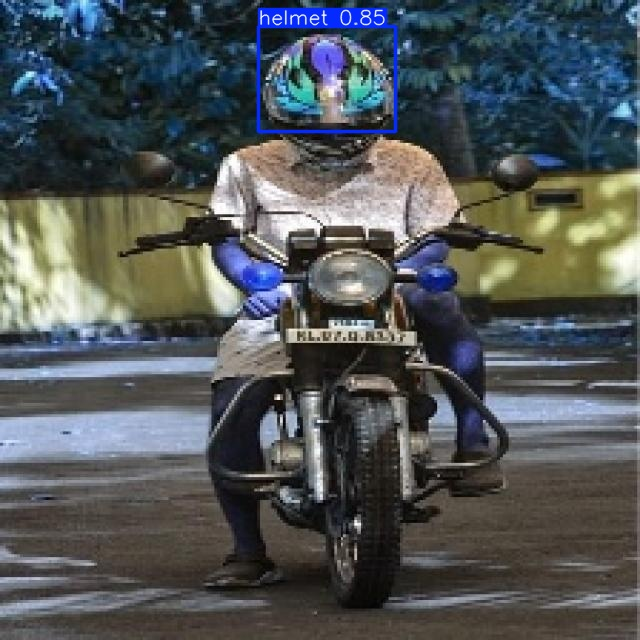

In [19]:
from ultralytics import YOLO
import os
from IPython.display import Image as IPImage, display

# Give your image manually
sample = r'C:\Users\ASUS\helmet_split\test\images\324_jpg.rf.C5kC4G0uIdZvuNJ2Sn9A.jpg'

print(f'Running inference on: {sample}')

best_model = YOLO(best_weights)

preds = best_model.predict(
    source   = sample,
    conf     = 0.25,
    save     = True,
    project  = os.path.join(os.getcwd(), 'runs'),
    name     = 'predict'
)

# Display result
save_dir   = preds[0].save_dir
img_name   = os.path.basename(sample)
result_img = os.path.join(save_dir, img_name)

if os.path.exists(result_img):
    display(IPImage(filename=result_img, width=640))
else:
    print(f'Result saved at: {save_dir}')

Running inference on: C:\Users\ASUS\helmet_split\test\images\37_jpg.rf.DtpnswFwBz4XJY6eVjYP.jpg

image 1/1 C:\Users\ASUS\helmet_split\test\images\37_jpg.rf.DtpnswFwBz4XJY6eVjYP.jpg: 640x640 1 no_helmet, 15.7ms
Speed: 5.7ms preprocess, 15.7ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\ASUS\runs\predict3


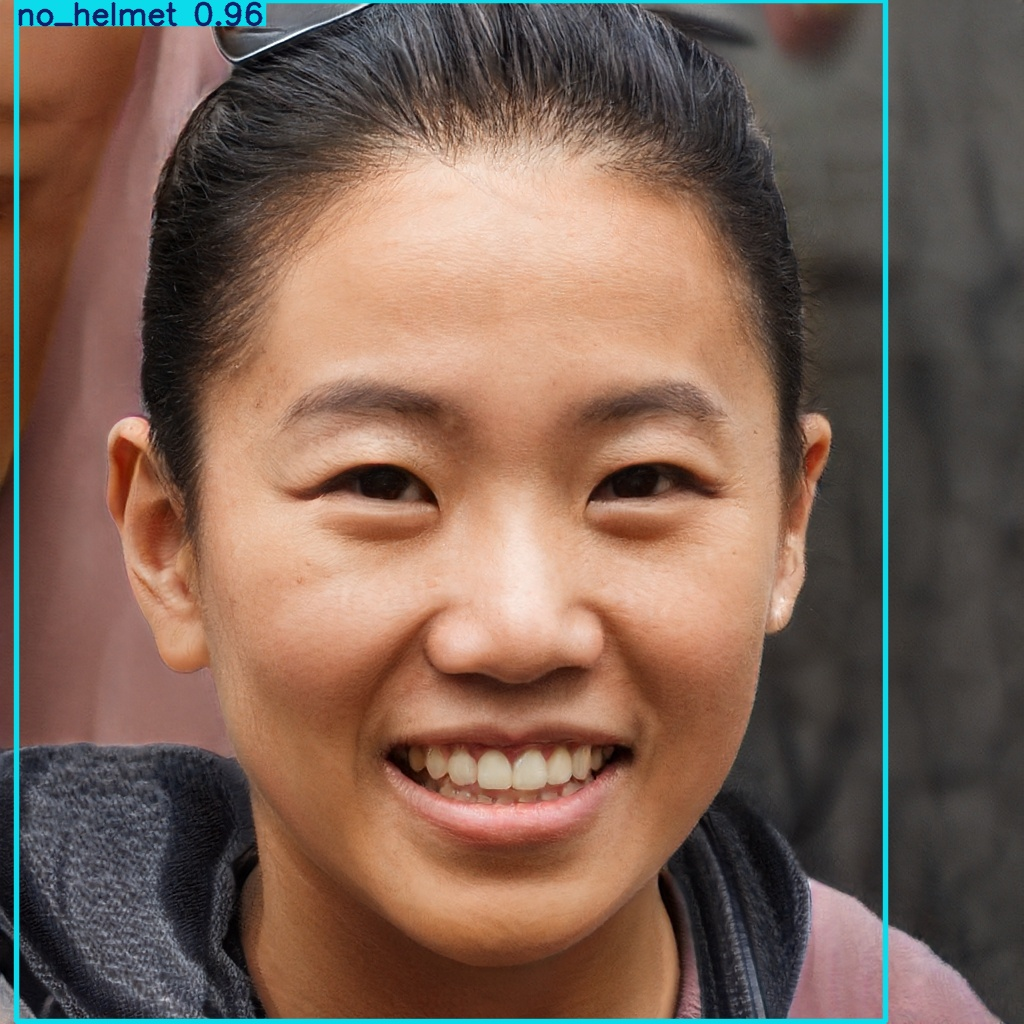

In [21]:
from ultralytics import YOLO
import os
from IPython.display import Image as IPImage, display

# Give your image manually
sample = r"C:\Users\ASUS\helmet_split\test\images\37_jpg.rf.DtpnswFwBz4XJY6eVjYP.jpg"

print(f'Running inference on: {sample}')

best_model = YOLO(best_weights)

preds = best_model.predict(
    source   = sample,
    conf     = 0.25,
    save     = True,
    project  = os.path.join(os.getcwd(), 'runs'),
    name     = 'predict'
)

# Display result
save_dir   = preds[0].save_dir
img_name   = os.path.basename(sample)
result_img = os.path.join(save_dir, img_name)

if os.path.exists(result_img):
    display(IPImage(filename=result_img, width=640))
else:
    print(f'Result saved at: {save_dir}')